# Dota 2 First-Pick Prediction — V2 Pipeline

End-to-end reproducible pipeline: **CandidateScorerNet** with captain/team priors, focal loss, ban masking, series context, data augmentation.

**Best result: Acc@5 = 0.425** (run `f753d96e509e4c7b98af9470921ecac7`)

Key improvements over V1:
- Candidate-scoring architecture (dot-product per hero, not 127-class softmax)
- Captain/team target encoding priors
- Rolling meta features
- Series context (game position + prior first-picks)
- League ID as feature
- Ban masking at inference
- Focal loss for rare heroes
- Data augmentation: side swap + ban permutation

## 1. Setup & Imports

In [1]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import json
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

print(f"PyTorch {torch.__version__}")

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print(f"Device: {DEVICE}")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

PyTorch 2.10.0
Device: mps


## 2. Load & Parse Data

In [2]:
df = pd.read_csv("../data/test_task_dataset.csv")
print(f"Dataset: {len(df):,} matches, {df.shape[1]} columns")
print(f"Date range: {pd.to_datetime(df['start_time'].min(), unit='s').date()} "
      f"to {pd.to_datetime(df['start_time'].max(), unit='s').date()}")
print(f"Unique first-pick heroes: {df['first_pick_hero'].nunique()}")

Dataset: 92,685 matches, 13 columns
Date range: 2023-01-01 to 2026-01-31
Unique first-pick heroes: 127


In [3]:
all_heroes = set(df["first_pick_hero"].unique())
bans_list, fp_teams = [], []

for pb_str in df["picks_bans"]:
    actions = json.loads(pb_str)
    for a in actions:
        all_heroes.add(a["hero_id"])
    actions_sorted = sorted(actions, key=lambda x: x["order"])
    bans = []
    fp_team = None
    for a in actions_sorted:
        if a["is_pick"]:
            fp_team = a["team"]
            break
        bans.append(a["hero_id"])
    bans_list.append(bans)
    fp_teams.append(fp_team)

df["pre_fp_bans"] = bans_list
df["first_pick_team"] = fp_teams
df["fp_captain"] = np.where(df["first_pick_team"] == 0,
                            df["radiant_captain"], df["dire_captain"])
df["fp_team_id"] = np.where(df["first_pick_team"] == 0,
                            df["radiant_team_id"], df["dire_team_id"])

hero_ids_sorted = sorted(all_heroes)
hero2idx = {h: i for i, h in enumerate(hero_ids_sorted)}
idx2hero = {i: h for h, i in hero2idx.items()}
print(f"Total heroes in vocab: {len(hero2idx)}")

Total heroes in vocab: 127


## 3. Train / Validation Split

In [4]:
VAL_SIZE = 200

train_df = df.iloc[:-VAL_SIZE].copy()
val_df = df.iloc[-VAL_SIZE:].copy()

target_heroes = sorted(train_df["first_pick_hero"].unique())
target2idx = {h: i for i, h in enumerate(target_heroes)}
idx2target = {i: h for h, i in target2idx.items()}
num_heroes = len(target2idx)

print(f"Train: {len(train_df):,} | Val: {len(val_df):,}")
print(f"Vocab: {len(hero2idx)} | Target classes: {num_heroes}")

Train: 92,485 | Val: 200
Vocab: 127 | Target classes: 127


## 4. Feature Engineering

### 4a. Captain/Team Target Encoding
Smoothed distribution P(hero | captain) and P(hero | team) based on historical first-picks.

In [5]:
def build_target_encoding(train_df, column, target2idx, alpha=20.0):
    num_classes = len(target2idx)
    global_counts = train_df["first_pick_hero"].value_counts()
    global_dist = np.zeros(num_classes, dtype=np.float32)
    for h, cnt in global_counts.items():
        if h in target2idx:
            global_dist[target2idx[h]] = cnt
    global_dist /= global_dist.sum() + 1e-8

    encoding = {}
    for entity_id, group in train_df.groupby(column):
        counts = group["first_pick_hero"].value_counts()
        n = len(group)
        empirical = np.zeros(num_classes, dtype=np.float32)
        for h, cnt in counts.items():
            if h in target2idx:
                empirical[target2idx[h]] = cnt
        empirical /= n + 1e-8
        smoothed = (n * empirical + alpha * global_dist) / (n + alpha)
        encoding[entity_id] = smoothed
    encoding["__default__"] = global_dist
    return encoding


captain_enc = build_target_encoding(train_df, "fp_captain", target2idx, alpha=20.0)
team_enc = build_target_encoding(train_df, "fp_team_id", target2idx, alpha=30.0)
print(f"Captain encodings: {len(captain_enc)-1} unique captains")
print(f"Team encodings: {len(team_enc)-1} unique teams")

Captain encodings: 5669 unique captains
Team encodings: 4037 unique teams


### 4b. Rolling Meta

In [6]:
META_WINDOW = 5000

recent = train_df.tail(META_WINDOW)["first_pick_hero"].value_counts()
meta_vec = np.zeros(num_heroes, dtype=np.float32)
for h, cnt in recent.items():
    if h in target2idx:
        meta_vec[target2idx[h]] = cnt
meta_vec /= meta_vec.sum() + 1e-8

top_meta = np.argsort(meta_vec)[-5:][::-1]
print(f"Top-5 meta heroes: {[idx2target[i] for i in top_meta]}")
print(f"Their frequencies: {[f'{meta_vec[i]:.3f}' for i in top_meta]}")

Top-5 meta heroes: [np.int64(64), np.int64(84), np.int64(87), np.int64(79), np.int64(5)]
Their frequencies: ['0.102', '0.054', '0.040', '0.038', '0.038']


### 4c. Series Features

In [7]:
def build_series_features(df, target2idx):
    num_classes = len(target2idx)
    game_pos = np.zeros(len(df), dtype=np.float32)
    series_prior = np.zeros((len(df), num_classes), dtype=np.float32)
    series_fps = {}
    for i, (_, row) in enumerate(df.iterrows()):
        sid = row.get("series_id", np.nan)
        if pd.isna(sid):
            continue
        if sid not in series_fps:
            series_fps[sid] = []
        prev_picks = series_fps[sid]
        game_pos[i] = len(prev_picks) / 3.0
        for prev_hero in prev_picks:
            if prev_hero in target2idx:
                series_prior[i, target2idx[prev_hero]] = 1.0
        series_fps[sid].append(row["first_pick_hero"])
    return game_pos, series_prior


train_game_pos, train_series_prior = build_series_features(train_df, target2idx)
val_game_pos, val_series_prior = build_series_features(val_df, target2idx)
print(f"Games with series history: {(train_game_pos > 0).sum():,} / {len(train_df):,}")

Games with series history: 49,004 / 92,485


### 4d. Data Augmentation

In [8]:
# Side swap: double data by swapping radiant/dire
swapped = train_df.copy()
swapped["first_pick_team"] = 1 - swapped["first_pick_team"]
swapped["fp_captain"] = np.where(
    swapped["first_pick_team"] == 0,
    swapped["radiant_captain"], swapped["dire_captain"])
swapped["fp_team_id"] = np.where(
    swapped["first_pick_team"] == 0,
    swapped["radiant_team_id"], swapped["dire_team_id"])
train_df_aug = pd.concat([train_df, swapped], ignore_index=True)
train_game_pos_aug = np.concatenate([train_game_pos, train_game_pos])
train_series_prior_aug = np.concatenate([train_series_prior, train_series_prior])
print(f"After side swap: {len(train_df_aug):,}")

After side swap: 184,970


### 4e. Build All Features

In [9]:
MAX_BAN_SEQ_LEN = 6
CONTEXT_SCALAR_DIM = 9


def build_ban_sequences(df, hero2idx, max_len=MAX_BAN_SEQ_LEN):
    ban_seqs = []
    for bans in df["pre_fp_bans"]:
        indices = [hero2idx[h] + 1 for h in bans[:max_len] if h in hero2idx]
        indices += [0] * (max_len - len(indices))
        ban_seqs.append(indices)
    return np.array(ban_seqs, dtype=np.int64)


def build_context(df, game_positions):
    dt = pd.to_datetime(df["start_time"], unit="s")
    series_type = df["series_type"].fillna(0).values.astype(np.float32)
    leagueid = df["leagueid"].fillna(0).values.astype(np.float32)
    league_max = max(leagueid.max(), 1.0)
    return np.column_stack([
        df["first_pick_team"].values.astype(np.float32),
        (dt.dt.year.values - 2023) / 3,
        dt.dt.month.values / 12,
        dt.dt.dayofweek.values / 6,
        dt.dt.hour.values / 24,
        df["cluster"].values.astype(np.float32) / 1000,
        series_type / 3,
        leagueid / league_max,
        game_positions,
    ]).astype(np.float32)


def build_prior_vectors(df, captain_enc, team_enc, meta_vec, num_heroes):
    default = captain_enc["__default__"]
    cap_priors, team_priors = [], []
    for _, row in df.iterrows():
        cap_id = row["fp_captain"]
        team_id = row.get("fp_team_id", np.nan)
        cap_priors.append(captain_enc.get(cap_id, default))
        team_priors.append(team_enc.get(team_id, default) if pd.notna(team_id) else default)
    return np.stack(cap_priors), np.stack(team_priors), np.tile(meta_vec, (len(df), 1))


def build_ban_mask(df, target2idx):
    num_classes = len(target2idx)
    masks = np.zeros((len(df), num_classes), dtype=np.float32)
    for i, bans in enumerate(df["pre_fp_bans"]):
        for h in bans:
            if h in target2idx:
                masks[i, target2idx[h]] = 1.0
    return masks


# Train features
train_bans = build_ban_sequences(train_df_aug, hero2idx)
train_ctx = build_context(train_df_aug, train_game_pos_aug)
train_tgt = train_df_aug["first_pick_hero"].map(target2idx).values
train_cap, train_team, train_meta = build_prior_vectors(
    train_df_aug, captain_enc, team_enc, meta_vec, num_heroes)

# Ban permutation augmentation
train_bans_perm = train_bans.copy()
for i in range(len(train_bans_perm)):
    nonzero = train_bans_perm[i] != 0
    n_nz = nonzero.sum()
    if n_nz > 1:
        perm = np.random.permutation(n_nz)
        train_bans_perm[i, :n_nz] = train_bans_perm[i, :n_nz][perm]

train_bans = np.concatenate([train_bans, train_bans_perm])
train_ctx = np.concatenate([train_ctx, train_ctx])
train_tgt = np.concatenate([train_tgt, train_tgt])
train_cap = np.concatenate([train_cap, train_cap])
train_team = np.concatenate([train_team, train_team])
train_meta = np.concatenate([train_meta, train_meta])
train_series_prior_final = np.concatenate([
    train_series_prior_aug, train_series_prior_aug])

# Val features
val_bans = build_ban_sequences(val_df, hero2idx)
val_ctx = build_context(val_df, val_game_pos)
val_heroes = val_df["first_pick_hero"].tolist()
val_cap, val_team, val_meta = build_prior_vectors(
    val_df, captain_enc, team_enc, meta_vec, num_heroes)
val_ban_mask = build_ban_mask(val_df, target2idx)

print(f"Train samples: {len(train_tgt):,}")
print(f"Val samples:   {len(val_heroes):,}")
print(f"Context dim:   {train_ctx.shape[1]}")

Train samples: 369,940
Val samples:   200
Context dim:   9


## 5. Move to Device

In [10]:
t_bans = torch.tensor(train_bans, dtype=torch.long, device=DEVICE)
t_ctx = torch.tensor(train_ctx, dtype=torch.float32, device=DEVICE)
t_tgt = torch.tensor(train_tgt, dtype=torch.long, device=DEVICE)
t_cap = torch.tensor(train_cap, dtype=torch.float32, device=DEVICE)
t_team = torch.tensor(train_team, dtype=torch.float32, device=DEVICE)
t_meta = torch.tensor(train_meta, dtype=torch.float32, device=DEVICE)
t_series = torch.tensor(train_series_prior_final, dtype=torch.float32, device=DEVICE)

v_bans = torch.tensor(val_bans, dtype=torch.long, device=DEVICE)
v_ctx = torch.tensor(val_ctx, dtype=torch.float32, device=DEVICE)
v_cap = torch.tensor(val_cap, dtype=torch.float32, device=DEVICE)
v_team = torch.tensor(val_team, dtype=torch.float32, device=DEVICE)
v_meta = torch.tensor(val_meta, dtype=torch.float32, device=DEVICE)
v_series = torch.tensor(val_series_prior, dtype=torch.float32, device=DEVICE)

print(f"Train on {DEVICE}: bans={t_bans.shape}, ctx={t_ctx.shape}")
print(f"Val on {DEVICE}:   bans={v_bans.shape}")

Train on mps: bans=torch.Size([369940, 6]), ctx=torch.Size([369940, 9])
Val on mps:   bans=torch.Size([200, 6])


## 6. Model: CandidateScorerNet

Architecture:
1. Ban tokens → Transformer Encoder (as SET, no positional encoding) → mean pool → `ban_repr`
2. Context scalars → Linear → `ctx_repr`
3. `[ban_repr, ctx_repr]` → MLP → `match_repr`
4. Each hero candidate has a learned embedding
5. Score = dot(match_repr, hero_emb) + learned_weights * log_priors(captain/team/meta/series)

In [11]:
class CandidateScorerNet(nn.Module):
    def __init__(self, vocab_size, num_heroes, embed_dim, hidden_dim,
                 context_dim, num_layers, nhead, dropout):
        super().__init__()
        self.num_heroes = num_heroes
        self.ban_embed = nn.Embedding(vocab_size + 1, embed_dim, padding_idx=0)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=nhead,
            dim_feedforward=embed_dim * 4,
            dropout=dropout, batch_first=True, activation="gelu")
        self.ban_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.ban_norm = nn.LayerNorm(embed_dim)
        self.ctx_proj = nn.Sequential(
            nn.Linear(context_dim, embed_dim), nn.GELU(), nn.Dropout(dropout * 0.5))
        self.match_head = nn.Sequential(
            nn.Linear(embed_dim * 2, hidden_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, embed_dim))
        self.hero_embed = nn.Embedding(num_heroes, embed_dim)
        self.prior_weights = nn.Parameter(torch.tensor([1.0, 0.5, 0.5, 0.3]))
        self.bias = nn.Parameter(torch.zeros(num_heroes))

    def forward(self, ban_seq, context, cap_prior, team_prior, meta_prior,
                series_prior=None):
        pad_mask = ban_seq == 0
        x = self.ban_embed(ban_seq)
        x = self.ban_encoder(x, src_key_padding_mask=pad_mask)
        x = self.ban_norm(x)
        mask = (~pad_mask).unsqueeze(-1).float()
        ban_repr = (x * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
        ctx_repr = self.ctx_proj(context)
        match_repr = self.match_head(torch.cat([ban_repr, ctx_repr], dim=1))
        hero_embs = self.hero_embed.weight
        dot_scores = match_repr @ hero_embs.T
        log_cap = torch.log(cap_prior + 1e-8)
        log_team = torch.log(team_prior + 1e-8)
        log_meta = torch.log(meta_prior + 1e-8)
        w = nn.functional.softplus(self.prior_weights)
        prior_scores = w[0] * log_cap + w[1] * log_team + w[2] * log_meta
        if series_prior is not None:
            prior_scores = prior_scores + w[3] * series_prior
        return dot_scores + prior_scores + self.bias


class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super().__init__()
        self.gamma = gamma

    def forward(self, logits, targets):
        log_probs = nn.functional.log_softmax(logits, dim=1)
        probs = log_probs.exp()
        nll = -log_probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        pt = probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        return (((1 - pt) ** self.gamma) * nll).mean()

## 7. Hyperparameters (Best Config)

In [12]:
CFG = dict(
    embed_dim=128, hidden_dim=256, nhead=2, num_layers=2,
    dropout=0.35, lr=8e-4, weight_decay=3e-5, batch_size=512,
    focal_gamma=2.0,
)
MAX_EPOCHS = 80
PATIENCE = 12

for k, v in CFG.items():
    print(f"  {k}: {v}")

  embed_dim: 128
  hidden_dim: 256
  nhead: 2
  num_layers: 2
  dropout: 0.35
  lr: 0.0008
  weight_decay: 3e-05
  batch_size: 512
  focal_gamma: 2.0


## 8. Evaluation Function

In [13]:
def accuracy_at_k(logits_np, val_heroes, idx2target, k=5, ban_mask_np=None):
    if ban_mask_np is not None:
        logits_np = logits_np.copy()
        logits_np[ban_mask_np > 0] = -np.inf
    hits = 0
    for i, hero in enumerate(val_heroes):
        top_k = [idx2target[j] for j in np.argsort(logits_np[i])[-k:][::-1]]
        if hero in top_k:
            hits += 1
    return hits / len(val_heroes)

## 9. Training

In [14]:
net = CandidateScorerNet(
    vocab_size=len(hero2idx), num_heroes=num_heroes,
    embed_dim=CFG["embed_dim"], hidden_dim=CFG["hidden_dim"],
    context_dim=CONTEXT_SCALAR_DIM, num_layers=CFG["num_layers"],
    nhead=CFG["nhead"], dropout=CFG["dropout"],
).to(DEVICE)

n_params = sum(p.numel() for p in net.parameters() if p.requires_grad)
print(f"Model parameters: {n_params:,}")

optimizer = torch.optim.AdamW(
    net.parameters(), lr=CFG["lr"], weight_decay=CFG["weight_decay"])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=MAX_EPOCHS, eta_min=CFG["lr"] * 0.01)
criterion = FocalLoss(gamma=CFG["focal_gamma"])

n = len(t_tgt)
bs = CFG["batch_size"]
best_acc5 = 0.0
best_loss = float("inf")
patience_ctr = 0
best_state = None
history = []

t0 = time.time()
for epoch in range(MAX_EPOCHS):
    net.train()
    perm = torch.randperm(n, device=DEVICE)
    total_loss, nb = 0.0, 0
    for start in range(0, n, bs):
        idx = perm[start:start + bs]
        logits = net(t_bans[idx], t_ctx[idx],
                     t_cap[idx], t_team[idx], t_meta[idx], t_series[idx])
        loss = criterion(logits, t_tgt[idx])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        nb += 1
    scheduler.step()
    avg_loss = total_loss / nb

    net.eval()
    with torch.no_grad():
        val_logits_np = net(v_bans, v_ctx, v_cap, v_team, v_meta, v_series).cpu().numpy()
    acc5 = accuracy_at_k(val_logits_np, val_heroes, idx2target, k=5, ban_mask_np=val_ban_mask)
    acc3 = accuracy_at_k(val_logits_np, val_heroes, idx2target, k=3, ban_mask_np=val_ban_mask)
    acc1 = accuracy_at_k(val_logits_np, val_heroes, idx2target, k=1, ban_mask_np=val_ban_mask)
    elapsed = time.time() - t0
    history.append({"epoch": epoch+1, "loss": avg_loss, "acc5": acc5, "acc3": acc3, "acc1": acc1})

    if acc5 > best_acc5:
        best_acc5 = acc5
        best_state = {k: v.cpu().clone() for k, v in net.state_dict().items()}
    if avg_loss < best_loss - 1e-4:
        best_loss = avg_loss
        patience_ctr = 0
    else:
        patience_ctr += 1

    if (epoch + 1) % 5 == 0 or epoch == 0:
        star = " ***" if acc5 >= best_acc5 else ""
        print(f"  ep {epoch+1:3d}/{MAX_EPOCHS}  loss={avg_loss:.4f}  "
              f"acc@1={acc1:.3f} @3={acc3:.3f} @5={acc5:.3f}  ({elapsed:.0f}s){star}")

    if patience_ctr >= PATIENCE:
        print(f"Early stop at epoch {epoch+1}")
        break

print(f"\nTraining: {time.time()-t0:.1f}s, Best Acc@5: {best_acc5:.3f}")

Model parameters: 529,539


/Users/aleksandryessin/Documents/datalouna_test/.venv/lib/python3.11/site-packages/torch/nn/modules/transformer.py:482: UserWarning: The operator 'aten::_nested_tensor_from_mask_left_aligned' is not currently supported on the MPS backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/mps/MPSFallback.mm:15.)
  elif do_mask_check and not torch._nested_tensor_from_mask_left_aligned(


  ep   1/80  loss=4.2762  acc@1=0.110 @3=0.235 @5=0.280  (10s) ***
  ep   5/80  loss=2.9112  acc@1=0.135 @3=0.295 @5=0.370  (54s) ***
  ep  10/80  loss=2.7743  acc@1=0.140 @3=0.305 @5=0.390  (108s) ***
  ep  15/80  loss=2.6925  acc@1=0.150 @3=0.320 @5=0.390  (158s)
  ep  20/80  loss=2.6254  acc@1=0.170 @3=0.320 @5=0.400  (208s)
  ep  25/80  loss=2.5614  acc@1=0.130 @3=0.285 @5=0.375  (246s)
  ep  30/80  loss=2.5076  acc@1=0.150 @3=0.270 @5=0.390  (273s)
  ep  35/80  loss=2.4525  acc@1=0.155 @3=0.290 @5=0.370  (303s)
  ep  40/80  loss=2.4030  acc@1=0.165 @3=0.320 @5=0.385  (334s)
  ep  45/80  loss=2.3621  acc@1=0.140 @3=0.290 @5=0.395  (366s)
  ep  50/80  loss=2.3190  acc@1=0.165 @3=0.275 @5=0.385  (398s)
  ep  55/80  loss=2.2841  acc@1=0.140 @3=0.310 @5=0.390  (429s)
  ep  60/80  loss=2.2542  acc@1=0.145 @3=0.305 @5=0.385  (463s)
  ep  65/80  loss=2.2318  acc@1=0.135 @3=0.300 @5=0.375  (497s)
  ep  70/80  loss=2.2165  acc@1=0.165 @3=0.300 @5=0.375  (531s)
  ep  75/80  loss=2.2060  acc@

## 10. Final Evaluation (Best Checkpoint)

In [15]:
if best_state is not None:
    net.load_state_dict(best_state)
    net.to(DEVICE)

net.eval()
with torch.no_grad():
    val_logits_np = net(v_bans, v_ctx, v_cap, v_team, v_meta, v_series).cpu().numpy()

final_acc5 = accuracy_at_k(val_logits_np, val_heroes, idx2target, k=5, ban_mask_np=val_ban_mask)
final_acc3 = accuracy_at_k(val_logits_np, val_heroes, idx2target, k=3, ban_mask_np=val_ban_mask)
final_acc1 = accuracy_at_k(val_logits_np, val_heroes, idx2target, k=1, ban_mask_np=val_ban_mask)

prior_w = nn.functional.softplus(net.prior_weights).detach().cpu().numpy()

print(f"FINAL (best checkpoint by Acc@5):")
print(f"  Accuracy@1: {final_acc1:.3f}")
print(f"  Accuracy@3: {final_acc3:.3f}")
print(f"  Accuracy@5: {final_acc5:.3f}  ({int(final_acc5 * 200)}/200)")
print(f"\nLearned prior weights:")
print(f"  captain={prior_w[0]:.3f}  team={prior_w[1]:.3f}  meta={prior_w[2]:.3f}  series={prior_w[3]:.3f}")

FINAL (best checkpoint by Acc@5):
  Accuracy@1: 0.150
  Accuracy@3: 0.325
  Accuracy@5: 0.420  (84/200)

Learned prior weights:
  captain=0.517  team=0.407  meta=0.501  series=1.050


## 11. Training Curves

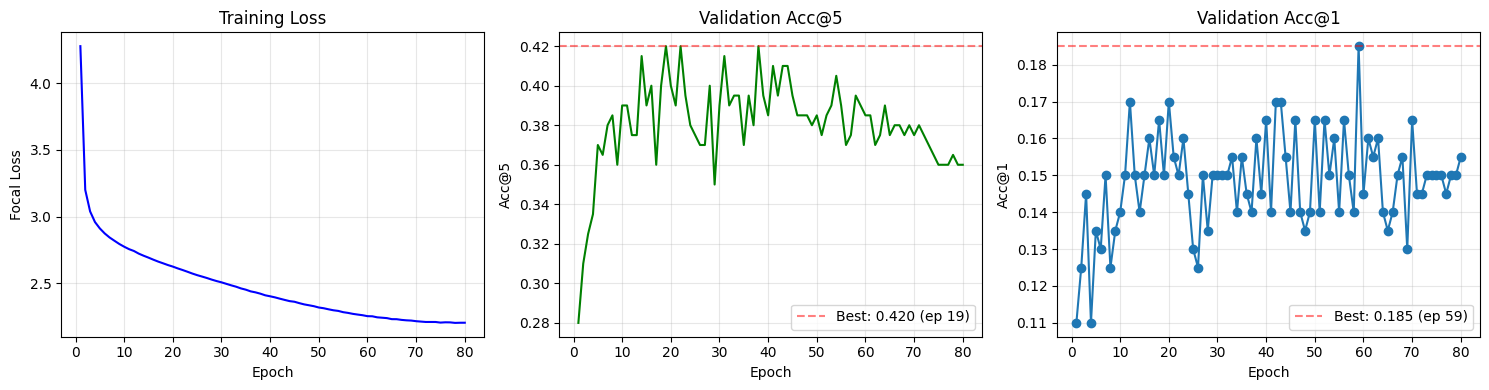

In [16]:
try:
    import matplotlib.pyplot as plt

    hist = pd.DataFrame(history)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(hist["epoch"], hist["loss"], "b-", linewidth=1.5)
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Focal Loss")
    axes[0].set_title("Training Loss"); axes[0].grid(True, alpha=0.3)

    for ax, col, color, title in [
        (axes[1], "acc5", "g", "Acc@5"),
        (axes[2], "acc1", "orange", "Acc@1"),
    ]:
        ax.plot(hist["epoch"], hist[col], f"{color[0]}-", linewidth=1.5)
        best_ep = hist.loc[hist[col].idxmax()]
        ax.axhline(y=best_ep[col], color="r", linestyle="--", alpha=0.5,
                   label=f'Best: {best_ep[col]:.3f} (ep {int(best_ep["epoch"])})')
        ax.set_xlabel("Epoch"); ax.set_ylabel(title)
        ax.set_title(f"Validation {title}"); ax.legend(); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
except ImportError:
    print("matplotlib not installed, skipping plot")

## 12. Prediction Examples

In [17]:
net.eval()
with torch.no_grad():
    logits = net(v_bans, v_ctx, v_cap, v_team, v_meta, v_series)
    logits_np = logits.cpu().numpy()
    logits_np[val_ban_mask > 0] = -np.inf
    probs = np.exp(logits_np - logits_np.max(axis=1, keepdims=True))
    probs /= probs.sum(axis=1, keepdims=True)

print(f"{'Match':>12}  {'True':>6}  {'Top-5 Predictions':>55}  {'Hit?'}")
print("-" * 90)
for i in range(min(20, len(val_df))):
    row = val_df.iloc[i]
    true_hero = row["first_pick_hero"]
    top5_idx = np.argsort(probs[i])[-5:][::-1]
    top5 = [(idx2target[j], probs[i][j]) for j in top5_idx]
    hit = "YES" if true_hero in [h for h, _ in top5] else "no"
    preds = ", ".join(f"{h}({p:.2f})" for h, p in top5)
    print(f"{row['match_id']:>12}  {true_hero:>6}  {preds:>55}  {hit}")

       Match    True                                        Top-5 Predictions  Hit?
------------------------------------------------------------------------------------------
  8668614455      86         5(0.15), 84(0.13), 87(0.10), 155(0.06), 10(0.06)  no
  8668629665      64         84(0.35), 5(0.06), 21(0.05), 128(0.04), 87(0.04)  no
  8668630585      79         28(0.36), 79(0.12), 19(0.07), 21(0.05), 96(0.05)  YES
  8668645424     128          5(0.12), 84(0.10), 11(0.09), 14(0.08), 86(0.05)  no
  8668649818      26        84(0.24), 64(0.13), 128(0.06), 26(0.05), 11(0.05)  YES
  8668660975      68         68(0.52), 75(0.05), 29(0.04), 39(0.03), 21(0.03)  YES
  8668667313      76          94(0.11), 14(0.10), 68(0.10), 5(0.08), 97(0.06)  no
  8668673059      74        84(0.20), 128(0.15), 64(0.10), 90(0.08), 27(0.04)  no
  8668694710      74         11(0.17), 87(0.08), 14(0.06), 84(0.06), 64(0.05)  no
  8668694979     155        84(0.18), 83(0.10), 64(0.07), 87(0.05), 111(0.04)  no
  

## 13. Results Comparison

| Model | Acc@1 | Acc@3 | Acc@5 |
|---|---|---|---|
| Popularity baseline | — | — | 0.110 |
| LightGBM (multiclass) | — | — | 0.125 |
| Bidirectional LSTM | — | — | 0.260 |
| Transformer V1 (default) | — | — | 0.320 |
| Transformer V1 (Optuna) | 0.090 | 0.230 | 0.405 |
| **V2 CandidateScorer** | **0.145** | **0.325** | **0.425** |